## Бізнес-контекст
Компанія VisionScan AI розробляє систему автоматичного розпізнавання рукописних цифр для обробки банківських документів.
Ваше завдання — створити першу версію моделі, яка класифікує цифри 0-9 за зображеннями, використовуючи PyTorch.

## Завдання 1
Підготуйте дані.
 - Використовуйте датасет MNIST із torchvision.datasets.
 - Завантажте навчальну і тестову вибірки.
 - Перетворіть зображення в тензори та нормалізуйте їх.
 - Створіть DataLoader із батчем розміром 64.

In [1]:
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# Завантажте навчальну і тестову вибірки.
train_dataset = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='data', train=False, download=True, transform=transform)

In [2]:
# Створіть DataLoader із батчем розміром 64.
from torch.utils.data import DataLoader
batch_size=64
train_loader = DataLoader(dataset=train_dataset, batch_size = batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size = batch_size, shuffle=False)
print(len(train_loader), len(test_loader))

938 157


64


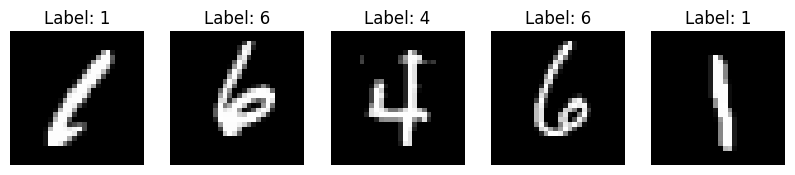

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

In [3]:
# Візуалізуємо кілька результатів
import matplotlib.pyplot as plt

train_iter = iter(train_loader)
images, labels = next(train_iter)
print(len(labels))

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i]}")
    plt.axis("off")
plt.show()
images[0]

## Завдання 2
Побудуйте просту згорткову нейронну мережу.
 - Використовуйте шари:
     - Conv2d(1, 16, kernel_size=3);
     - ReLU();
     - MaxPool2d(2);
     - Flatten();
     - Linear(16 * 13 * 13, 10).
 - Функція втрат — CrossEntropyLoss,
 - оптимізатор — Adam(lr=0.001).
 - Навчіть модель 10 епох.

In [4]:
import torch.nn as nn
import torch.optim as optim

class ConvNN(nn.Module):
    def __init__(self):
        super(ConvNN, self).__init__()
        self.conv = nn.Conv2d(
            in_channels=1,   # сірий - 1, кольоровий (RGB) 
            out_channels=16, # кількість ознак
            kernel_size=3    # "вікно" згортки 3х3
        )
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2) # "вікно" 2х2
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 13 * 13, 10)
    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

model = ConvNN()
loss_f = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Навчіть модель 10 епох.
epochs = 10
losses = []
for epoch in range(epochs) : 
    total_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = loss_f(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)
    print(f"Epoch: {epoch+1}, Loss: {total_loss}")

Epoch: 1, Loss: 198.63092232495546
Epoch: 2, Loss: 72.69937924854457
Epoch: 3, Loss: 57.561067822854966
Epoch: 4, Loss: 47.96384659293108
Epoch: 5, Loss: 41.653236185899004
Epoch: 6, Loss: 37.51404421508778
Epoch: 7, Loss: 33.5964279177133
Epoch: 8, Loss: 30.42363359197043


## Завдання 3
Відстежуйте та візуалізуйте процес навчання.
 - Виведіть втрати за епохами.
 - Побудуйте графік залежності loss від епох.
 - Збережіть модель у файл mnist_cnn.pth.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([i for i in range(10)], losses, 'r-o')
plt.grid()
plt.show()

## Завдання 4
Перевірте точність моделі на тестовій вибірці та оформіть результати:

|Метрика|Значення|
|-|-|
|Accuracy|...|
|Loss|...|

In [ ]:
correct = 0
total = 0
mis = []
with torch.no_grad():
    for images, labels in test_loader :
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += len(labels)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)) :
            if predicted[i] != labels[i] :
                mis.append({
                    "label": labels[i],
                    "predicted": predicted[i],
                    "images": images[i]
                })
print(len(mis))
# точність: відсоток правильних передбачень
# втрати: відсоток помилок
# mis - приклади помилок (неправильних передбачень)

In [ ]:


plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(mis[i]["images"].squeeze(), cmap="gray")
    plt.title(f"True: {mis[i]["label"]}, Pred: {mis[i]["predicted"]}")
    plt.axis("off")
plt.show()
images[0]

In [ ]:
from IPython.display import Markdown as md
md(f""" 
|Метрика|Значення|
|-|-|
|Accuracy|{(correct * 100) / total}%|
|Loss|{(len(mis) * 100) / total}%|
""")